(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

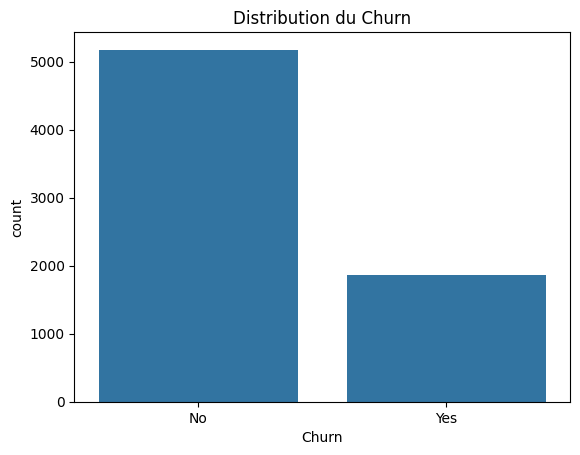

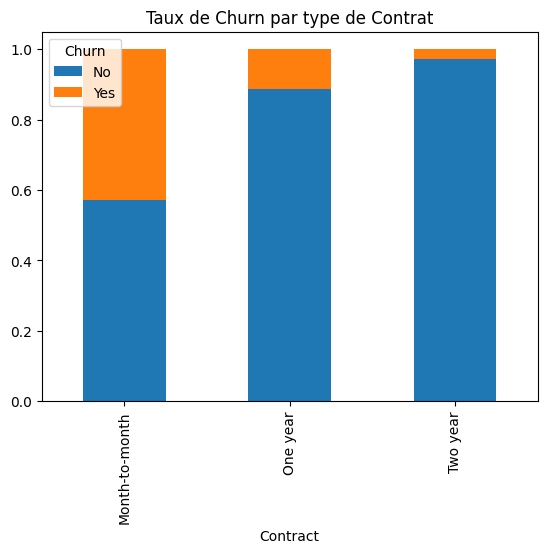

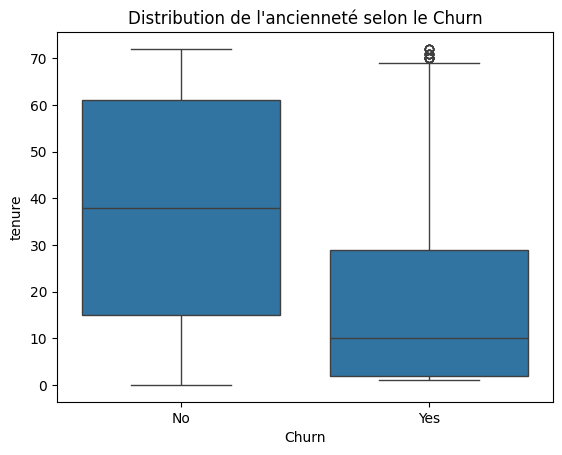

In [1]:
# notebooks/01_eda.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger les données
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv') # Le nom exact peut varier
print(df.shape)
df.head()

# 2. Infos générales
df.info()
# -> On voit que 'TotalCharges' est un objet (string) alors que c'est un nombre. Problème à corriger !

# 3. Statistiques
df.describe()

# 4. Valeurs manquantes
df.isnull().sum()
# -> Bonne nouvelle, très peu de valeurs manquantes dans 'TotalCharges' ?

# Regardons 'TotalCharges' de plus près
# Remplacer les espaces vides par NaN et convertir en numérique
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())
# -> Ah oui, il y a des valeurs vides (probablement pour les nouveaux clients qui n'ont pas encore de facture).

# 5. Visualisation de la cible (Churn)
sns.countplot(x='Churn', data=df)
plt.title('Distribution du Churn')
plt.show()
# -> Le dataset est déséquilibré (moins de 'Yes' que de 'No').

# 6. Features catégorielles vs Churn
# Exemple : Contrat
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Taux de Churn par type de Contrat')
plt.show()
# -> On voit que les clients en engagement mensuel (Month-to-month) se barrent plus.

# 7. Features numériques vs Churn
# Exemple : Tenure (ancienneté)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Distribution de l\'ancienneté selon le Churn')
plt.show()
# -> Les clients qui partent ont tendance à être moins anciens.

# 8. Conclusion pour la modélisation
# - Target: 'Churn' (Oui/Non) -> à encoder en 1/0.
# - Problème: 'TotalCharges' est string avec des vides. Il faut les traiter (supprimer ou imputer).
# - Features: 'customerID' est un ID unique, à supprimer.
# - Features catégorielles: 'Gender', 'Partner', 'PhoneService', 'Contract', etc. -> à encoder (OneHotEncoding).
# - Features numériques: 'tenure', 'MonthlyCharges', 'TotalCharges'.